<a href="https://colab.research.google.com/github/amyashima27-ops/C-lculo.Num-rico/blob/main/Copy_of_ativ1CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Valor  n         Método  Aproximação  Erro absoluto  Erro relativo  Erro percentual
   x1  0    Truncamento       3.0000       0.141593   4.507034e-02         4.507034
   x1  0 Arredondamento       3.0000       0.141593   4.507034e-02         4.507034
   x1  1    Truncamento       3.1000       0.041593   1.323935e-02         1.323935
   x1  1 Arredondamento       3.1000       0.041593   1.323935e-02         1.323935
   x1  2    Truncamento       3.1400       0.001593   5.069562e-04         0.050696
   x1  2 Arredondamento       3.1400       0.001593   5.069562e-04         0.050696
   x1  3    Truncamento       3.1410       0.000593   1.886464e-04         0.018865
   x1  3 Arredondamento       3.1420       0.000407   1.296635e-04         0.012966
   x1  4    Truncamento       3.1415       0.000093   2.949141e-05         0.002949
   x1  4 Arredondamento       3.1416       0.000007   2.339578e-06         0.000234
   x2  0    Truncamento      98.0000       0.765430   7.749979e-03         0

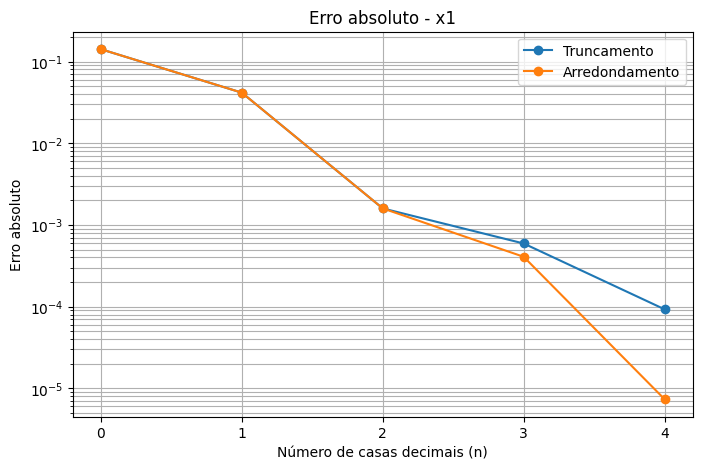

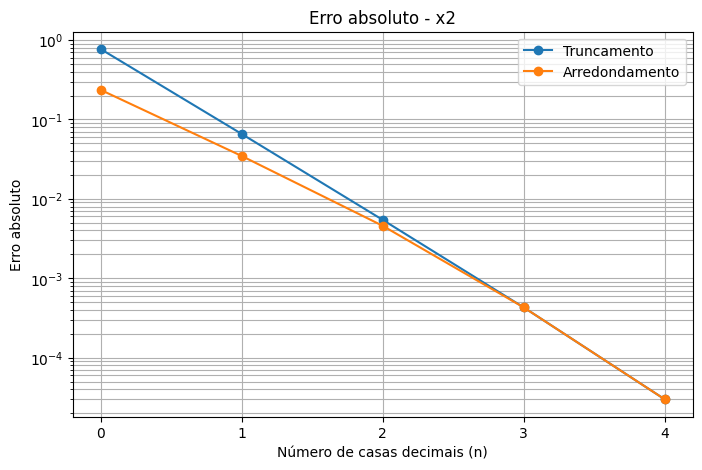

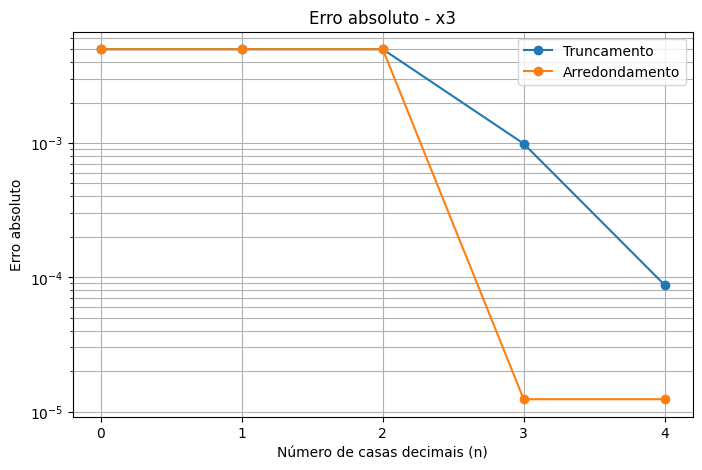

x1, n=0: Truncamento = 0.14159265, Arredondamento = 0.14159265 -> Truncamento possui erro menor
x1, n=1: Truncamento = 0.04159265, Arredondamento = 0.04159265 -> Truncamento possui erro menor
x1, n=2: Truncamento = 0.00159265, Arredondamento = 0.00159265 -> Truncamento possui erro menor
x1, n=3: Truncamento = 0.00059265, Arredondamento = 0.00040735 -> Arredondamento possui erro menor
x1, n=4: Truncamento = 9.265e-05, Arredondamento = 7.35e-06 -> Arredondamento possui erro menor
x2, n=0: Truncamento = 0.76543, Arredondamento = 0.23457 -> Arredondamento possui erro menor
x2, n=1: Truncamento = 0.06543, Arredondamento = 0.03457 -> Arredondamento possui erro menor
x2, n=2: Truncamento = 0.00543, Arredondamento = 0.00457 -> Arredondamento possui erro menor
x2, n=3: Truncamento = 0.00043, Arredondamento = 0.00043 -> Truncamento possui erro menor
x2, n=4: Truncamento = 3e-05, Arredondamento = 3e-05 -> Truncamento possui erro menor
x3, n=0: Truncamento = 0.00498765, Arredondamento = 0.00498765

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt

valores = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765
}
casas_decimais = [0, 1, 2, 3, 4] #casas decimais

def truncar(x, n): #função para truncar
    fator = 10 ** n
    return math.trunc(x * fator) / fator

#calcuando erros
def erro_absoluto(valor_real, aproximacao):
    return abs(valor_real - aproximacao)


def erro_relativo(valor_real, aproximacao):
    return erro_absoluto(valor_real, aproximacao) / abs(valor_real)


def erro_percentual(valor_real, aproximacao):
    return erro_relativo(valor_real, aproximacao) * 100

resultados = []

for nome, valor in valores.items():

    for n in casas_decimais:

        # Truncamento
        valor_truncado = truncar(valor, n)

        # Arredondamento
        valor_arredondado = round(valor, n)

        # Erros do truncamento
        Ea_trunc = erro_absoluto(valor, valor_truncado)
        Er_trunc = erro_relativo(valor, valor_truncado)
        Ep_trunc = erro_percentual(valor, valor_truncado)

        resultados.append({
            "Valor": nome,
            "n": n,
            "Método": "Truncamento",
            "Aproximação": valor_truncado,
            "Erro absoluto": Ea_trunc,
            "Erro relativo": Er_trunc,
            "Erro percentual": Ep_trunc
        })

        # Erros do arredondamento
        Ea_arred = erro_absoluto(valor, valor_arredondado)
        Er_arred = erro_relativo(valor, valor_arredondado)
        Ep_arred = erro_percentual(valor, valor_arredondado)

        resultados.append({
            "Valor": nome,
            "n": n,
            "Método": "Arredondamento",
            "Aproximação": valor_arredondado,
            "Erro absoluto": Ea_arred,
            "Erro relativo": Er_arred,
            "Erro percentual": Ep_arred
        })


#tabela
tabela_A = pd.DataFrame(resultados)
print(tabela_A.to_string(index=False))


for nome in valores:

    print(f"\n\n========== {nome} ==========\n")

    tabela_valor = tabela_A[tabela_A["Valor"] == nome]

    print(tabela_valor.to_string(index=False))

#gráico
for nome in valores:

    dados = tabela_A[tabela_A["Valor"] == nome]

    truncamento = dados[dados["Método"] == "Truncamento"]
    arredondamento = dados[dados["Método"] == "Arredondamento"]

    plt.figure(figsize=(8, 5))

    plt.plot(
        truncamento["n"],
        truncamento["Erro absoluto"],
        marker="o",
        label="Truncamento"
    )

    plt.plot(
        arredondamento["n"],
        arredondamento["Erro absoluto"],
        marker="o",
        label="Arredondamento"
    )

    # Escala logarítmica no eixo y
    plt.yscale("log")

    plt.xlabel("Número de casas decimais (n)")
    plt.ylabel("Erro absoluto")

    plt.title(f"Erro absoluto - {nome}")

    plt.xticks(casas_decimais)

    plt.grid(True, which="both")
    plt.legend()

    plt.show()

#comparando

for nome in valores:

    dados = tabela_A[tabela_A["Valor"] == nome]

    for n in casas_decimais:

        erro_t = dados[
            (dados["n"] == n) &
            (dados["Método"] == "Truncamento")
        ]["Erro absoluto"].iloc[0]

        erro_a = dados[
            (dados["n"] == n) &
            (dados["Método"] == "Arredondamento")
        ]["Erro absoluto"].iloc[0]

        if erro_a < erro_t:
            resultado = "Arredondamento possui erro menor"
            if erro_a == erro_t:
                resultado = "Ambos possuem erro igual"
        else:
            resultado = "Truncamento possui erro menor"

        print(
            f"{nome}, n={n}: "
            f"Truncamento = {erro_t:.10g}, "
            f"Arredondamento = {erro_a:.10g} -> "
            f"{resultado}"
        )


ESTATÍSTICAS DAS SÉRIES

       Série  Média  Mínimo  Máximo  Amplitude  Desvio-padrão amostral
   Originais 121.12   119.8   122.4        2.6                0.833733
Arredondados 121.10   120.0   122.0        2.0                0.875595
   Truncados 120.70   119.0   122.0        3.0                0.948683

ERROS DAS MÉDIAS

       Série  Média aproximada  Erro absoluto  Erro relativo  Erro percentual (%)
Arredondados             121.1           0.02       0.000165             0.016513


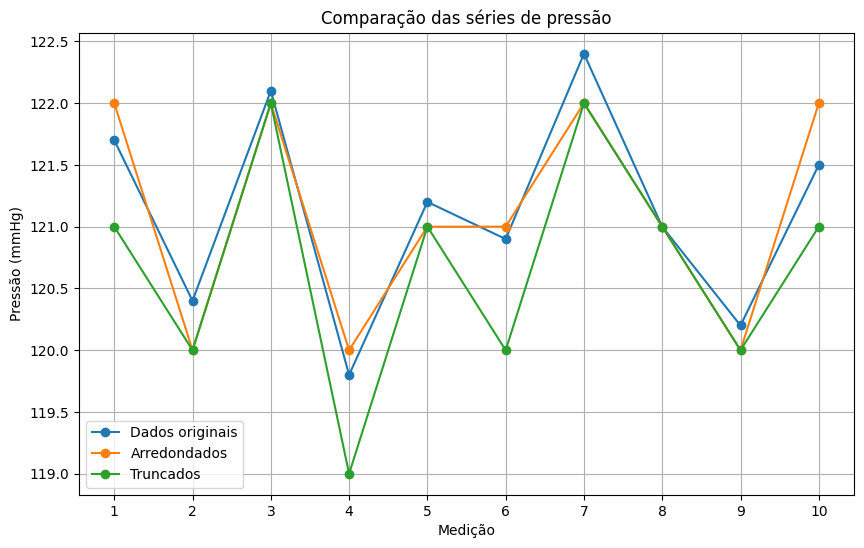

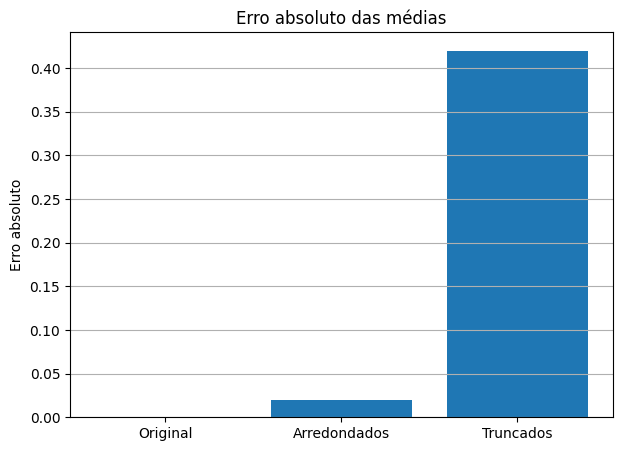

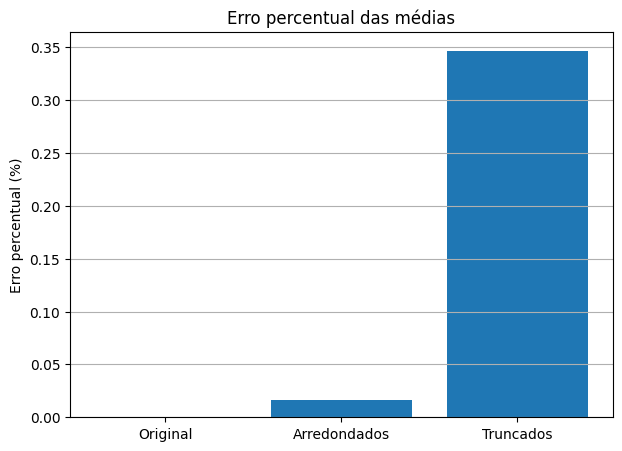

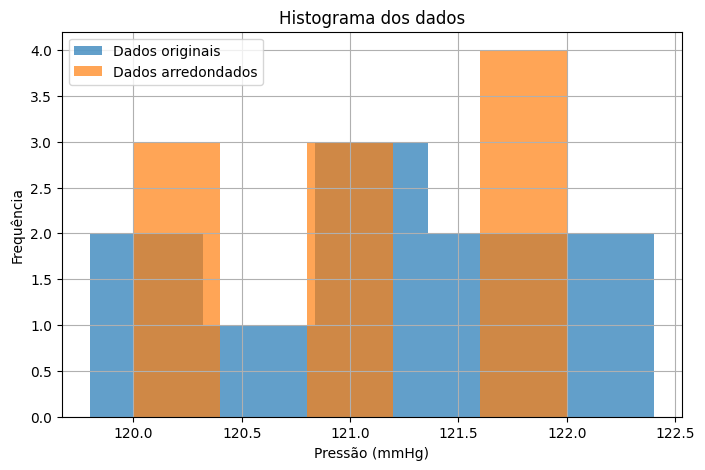

In [ ]:
#medidas de pressão arterial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


dados_originais = np.array([
    121.7,
    120.4,
    122.1,
    119.8,
    121.2,
    120.9,
    122.4,
    121.0,
    120.2,
    121.5
])


#séries
# 1. Dados originais
originais = dados_originais

# 2. Dados arredondados para o inteiro mais próximo
arredondados = np.round(dados_originais)

# 3. Dados truncados para números inteiros
truncados = np.trunc(dados_originais)

#função para calcular média, mínimo, máximo, amplitude e desvio
def calcular_estatisticas(dados):

    media = np.mean(dados)
    minimo = np.min(dados)
    maximo = np.max(dados)
    amplitude = maximo - minimo
    desvio_padrao = np.std(dados, ddof=1)

    return media, minimo, maximo, amplitude, desvio_padrao
#calculando
estatisticas_originais = calcular_estatisticas(originais)

estatisticas_arredondados = calcular_estatisticas(arredondados)

estatisticas_truncados = calcular_estatisticas(truncados)

#tabela das estastísticas
tabela_estatisticas = pd.DataFrame({

    "Série": [
        "Originais",
        "Arredondados",
        "Truncados"
    ],

    "Média": [
        estatisticas_originais[0],
        estatisticas_arredondados[0],
        estatisticas_truncados[0]
    ],

    "Mínimo": [
        estatisticas_originais[1],
        estatisticas_arredondados[1],
        estatisticas_truncados[1]
    ],

    "Máximo": [
        estatisticas_originais[2],
        estatisticas_arredondados[2],
        estatisticas_truncados[2]
    ],

    "Amplitude": [
        estatisticas_originais[3],
        estatisticas_arredondados[3],
        estatisticas_truncados[3]
    ],

    "Desvio-padrão amostral": [
        estatisticas_originais[4],
        estatisticas_arredondados[4],
        estatisticas_truncados[4]
    ]
})


print("\n======================================")
print("ESTATÍSTICAS DAS SÉRIES")
print("======================================\n")

print(tabela_estatisticas.to_string(index=False))

#erros das médias
media_referencia = np.mean(dados_originais)
def calcular_erros (media_referencia, media):

    erro_absoluto = abs(media_referencia - media)

    erro_relativo = (
        erro_absoluto / abs(media_referencia)
    )

    erro_percentual = erro_relativo * 100

    return erro_absoluto, erro_relativo, erro_percentual

# Erros
erros_dados = calcular_erros(
    media_referencia,
    estatisticas_originais[0]
)

erros_arredondada = calcular_erros(
    media_referencia,
    estatisticas_arredondados[0]
)

erros_truncados = calcular_erros(
    media_referencia,
    estatisticas_truncados[0]
)
media_arredondada = round(np.mean(arredondados), 1)
erros_media_arredondada = calcular_erros(
    media_referencia,
    media_arredondada
)
#tabela dos erros da media aproximada com a de referencia
tabela_erros = pd.DataFrame({

    "Série": [
        "Arredondados",
    ],

    "Média aproximada": [
        media_arredondada,
    ],

    "Erro absoluto": [
        erros_media_arredondada[0],
    ],

    "Erro relativo": [
        erros_media_arredondada[1],
    ],

    "Erro percentual (%)": [
        erros_media_arredondada[2],
    ]
})
print("\n======================================")
print("ERROS DAS MÉDIAS")
print("======================================\n")

print(tabela_erros.to_string(index=False))

#gráfico das medições
indices = np.arange(1, 11)

plt.figure(figsize=(10, 6))

plt.plot(
    indices,
    originais,
    marker="o",
    label="Dados originais"
)

plt.plot(
    indices,
    arredondados,
    marker="o",
    label="Arredondados"
)

plt.plot(
    indices,
    truncados,
    marker="o",
    label="Truncados"
)


plt.xlabel("Medição")
plt.ylabel("Pressão (mmHg)")

plt.title("Comparação das séries de pressão")

plt.xticks(indices)

plt.grid(True)
plt.legend()

plt.show()

#gráfico dos erros absolutos
nomes = ["Original","Arredondados", "Truncados"]

erros_absolutos = [
    erros_dados[0],
    erros_arredondada[0],
    erros_truncados[0]]

plt.figure(figsize=(7, 5))

plt.bar(
    nomes,
    erros_absolutos
)

plt.ylabel("Erro absoluto")

plt.title("Erro absoluto das médias")

plt.grid(axis="y")

plt.show()

#gráfico erros percentuais
erros_percentuais = [
    erros_dados[2],
    erros_arredondada[2],
    erros_truncados[2],
]

plt.figure(figsize=(7, 5))

plt.bar(
    nomes,
    erros_percentuais
)

plt.ylabel("Erro percentual (%)")

plt.title("Erro percentual das médias")

plt.grid(axis="y")

plt.show()

#histogramas
plt.figure(figsize=(8, 5))

plt.hist(
    originais,
    bins=5,
    alpha=0.7,
    label="Dados originais"
)

plt.hist(
    arredondados,
    bins=5,
    alpha=0.7,
    label="Dados arredondados"
)

plt.xlabel("Pressão (mmHg)")
plt.ylabel("Frequência")

plt.title("Histograma dos dados")

plt.legend()
plt.grid(True)

plt.show()

Q referência = 2.757420751950813e-07 m³/s
                   Cenário      Q (m³/s)  Erro absoluto  Erro relativo  \
0         Raio arredondado  2.757421e-07   0.000000e+00       0.000000   
1            Raio truncado  2.757421e-07   0.000000e+00       0.000000   
2  Viscosidade arredondada  2.412743e-07   3.446776e-08       0.125000   
3     Viscosidade truncada  3.216991e-07   4.595701e-08       0.166667   
4      Pressão arredondada  2.757421e-07   0.000000e+00       0.000000   
5         Pressão truncada  2.757421e-07   0.000000e+00       0.000000   
6         Tudo arredondado  2.412743e-07   3.446776e-08       0.125000   
7            Tudo truncado  3.216991e-07   4.595701e-08       0.166667   

   Erro percentual  
0         0.000000  
1         0.000000  
2        12.500000  
3        16.666667  
4         0.000000  
5         0.000000  
6        12.500000  
7        16.666667  


/tmp/ipykernel_3461/585815880.py:177: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,5))


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

...

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

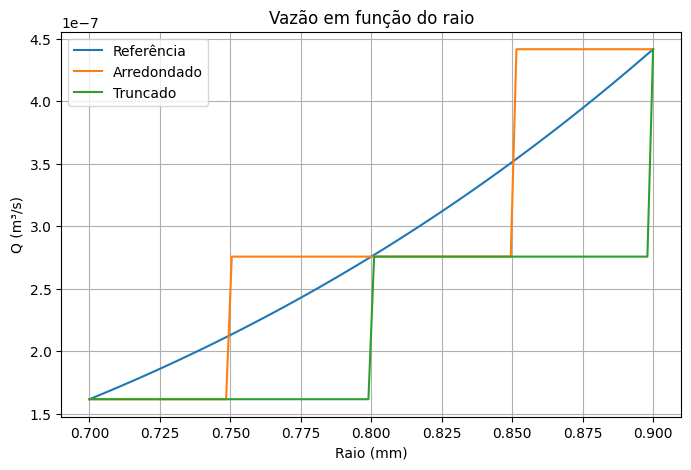

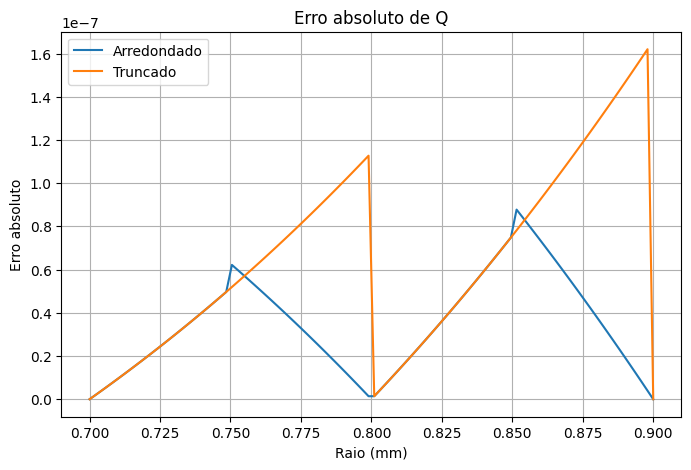

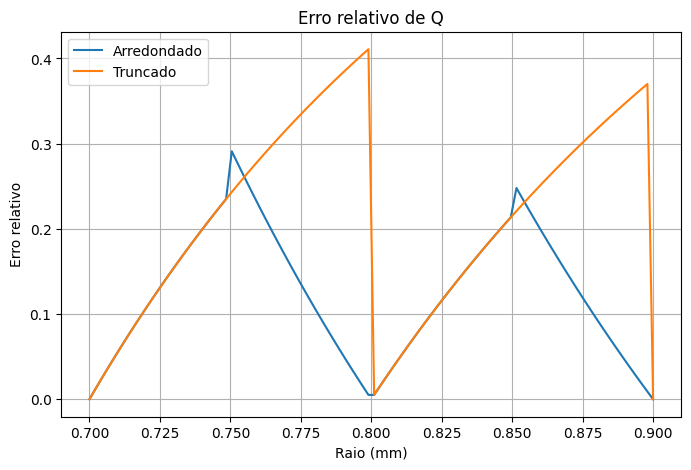

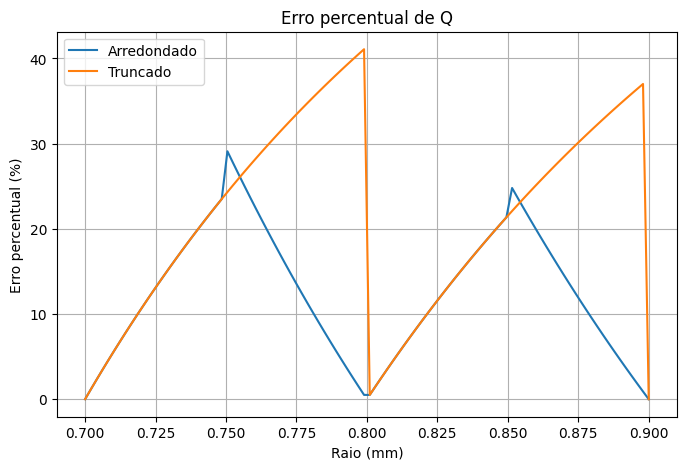

In [ ]:
#vazão em um tubo de pequeno diâmetro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

#Dados
r_mm = 0.80          # mm
L = 0.20             # m
mu = 3.5e-3          # Pa.s
delta_p = 1200       # Pa

# Conversão para metros
r = r_mm / 1000

#calculando Q
def vazao(r, delta_p, mu, L):
    return (np.pi * r**4 * delta_p) / (8 * mu * L)

def erro_absoluto(real, aprox):
    return abs(real - aprox)

def erro_relativo(real, aprox):
    return abs(real - aprox) / abs(real)

def erro_percentual(real, aprox):
    return erro_relativo(real, aprox) * 100

def truncar(x, n):
    fator = 10**n
    return math.trunc(x * fator) / fator

Q_ref = vazao(r, delta_p, mu, L)

print("Q referência =", Q_ref, "m³/s")

resultados = []

#precisão do raio
r_arred_mm = round(r_mm, 1)
r_trunc_mm = truncar(r_mm, 1)

r_arred = r_arred_mm / 1000
r_trunc = r_trunc_mm / 1000

Q_r_arred = vazao(r_arred, delta_p, mu, L)
Q_r_trunc = vazao(r_trunc, delta_p, mu, L)

#precisão da viscosidade
mu_arred = round(mu, 3)
mu_trunc = truncar(mu, 3)

Q_mu_arred = vazao(r, delta_p, mu_arred, L)
Q_mu_trunc = vazao(r, delta_p, mu_trunc, L)

#precisão da pressão
dp_arred = round(delta_p, -2)
dp_trunc = truncar(delta_p, -2)

Q_dp_arred = vazao(r, dp_arred, mu, L)
Q_dp_trunc = vazao(r, dp_trunc, mu, L)

#todas aproximações
Q_total_arred = vazao(
    r_arred,
    dp_arred,
    mu_arred,
    L
)

Q_total_trunc = vazao(
    r_trunc,
    dp_trunc,
    mu_trunc,
    L
)

#tabela
cenarios = {

    "Raio arredondado": Q_r_arred,
    "Raio truncado": Q_r_trunc,
    "Viscosidade arredondada": Q_mu_arred,
    "Viscosidade truncada": Q_mu_trunc,
    "Pressão arredondada": Q_dp_arred,
    "Pressão truncada": Q_dp_trunc,
    "Tudo arredondado": Q_total_arred,
    "Tudo truncado": Q_total_trunc
}

for nome, Q in cenarios.items():

    Ea = erro_absoluto(Q_ref, Q)
    Er = erro_relativo(Q_ref, Q)
    Ep = erro_percentual(Q_ref, Q)

    resultados.append([
        nome,
        Q,
        Ea,
        Er,
        Ep
    ])

tabela = pd.DataFrame(
    resultados,
    columns=[
        "Cenário",
        "Q (m³/s)",
        "Erro absoluto",
        "Erro relativo",
        "Erro percentual"
    ]
)

print(tabela)

#variando o raio
raios_mm = np.linspace(0.70, 0.90, 100)

Q_ref_lista = []
Q_arred_lista = []
Q_trunc_lista = []

erro_abs_arred = []
erro_abs_trunc = []

erro_rel_arred = []
erro_rel_trunc = []

erro_perc_arred = []
erro_perc_trunc = []

for raio_mm in raios_mm:

    r_real = raio_mm / 1000

    r_a = round(raio_mm, 1) / 1000

    r_t = truncar(raio_mm, 1) / 1000

    Q_real = vazao(r_real, delta_p, mu, L)

    Q_a = vazao(r_a, delta_p, mu, L)

    Q_t = vazao(r_t, delta_p, mu, L)

    Q_ref_lista.append(Q_real)
    Q_arred_lista.append(Q_a)
    Q_trunc_lista.append(Q_t)

    erro_abs_arred.append(
        erro_absoluto(Q_real, Q_a)
    )

    erro_abs_trunc.append(
        erro_absoluto(Q_real, Q_t)
    )

    erro_rel_arred.append(
        erro_relativo(Q_real, Q_a)
    )

    erro_rel_trunc.append(
        erro_relativo(Q_real, Q_t)
    )

    erro_perc_arred.append(
        erro_percentual(Q_real, Q_a)
    )

    erro_perc_trunc.append(
        erro_percentual(Q_real, Q_t)
    )

#gráfico
    plt.figure(figsize=(8,5))

plt.plot(raios_mm, Q_ref_lista, label="Referência")

plt.plot(raios_mm, Q_arred_lista,
         label="Arredondado")

plt.plot(raios_mm, Q_trunc_lista,
         label="Truncado")

plt.xlabel("Raio (mm)")
plt.ylabel("Q (m³/s)")
plt.title("Vazão em função do raio")

plt.grid()
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(raios_mm, erro_abs_arred,
         label="Arredondado")

plt.plot(raios_mm, erro_abs_trunc,
         label="Truncado")

plt.xlabel("Raio (mm)")
plt.ylabel("Erro absoluto")

plt.title("Erro absoluto de Q")

plt.grid()
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(raios_mm, erro_rel_arred,
         label="Arredondado")

plt.plot(raios_mm, erro_rel_trunc,
         label="Truncado")

plt.xlabel("Raio (mm)")
plt.ylabel("Erro relativo")

plt.title("Erro relativo de Q")

plt.grid()
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(raios_mm, erro_perc_arred,
         label="Arredondado")

plt.plot(raios_mm, erro_perc_trunc,
         label="Truncado")

plt.xlabel("Raio (mm)")
plt.ylabel("Erro percentual (%)")

plt.title("Erro percentual de Q")

plt.grid()
plt.legend()

plt.show()

Raio = 5.0000000000000004e-08 m
Comprimento = 9.999999999999999e-06 m
Vazão de referência = 3.506241800881467e-19 m³/s
    Δr (nm)  r- (nm)  r+ (nm)  Q(r-) (m³/s)  Q(r+) (m³/s)  \
0       0.1     49.9     50.1  3.478276e-19  3.534376e-19   
1       0.2     49.8     50.2  3.450478e-19  3.562679e-19   
2       0.3     49.7     50.3  3.422846e-19  3.591152e-19   
3       0.4     49.6     50.4  3.395381e-19  3.619795e-19   
4       0.5     49.5     50.5  3.368082e-19  3.648609e-19   
5       0.6     49.4     50.6  3.340947e-19  3.677595e-19   
6       0.7     49.3     50.7  3.313977e-19  3.706753e-19   
7       0.8     49.2     50.8  3.287171e-19  3.736085e-19   
8       0.9     49.1     50.9  3.260527e-19  3.765590e-19   
9       1.0     49.0     51.0  3.234046e-19  3.795269e-19   
10      1.1     48.9     51.1  3.207726e-19  3.825123e-19   
11      1.2     48.8     51.2  3.181567e-19  3.855154e-19   
12      1.3     48.7     51.3  3.155569e-19  3.885360e-19   
13      1.4     48.6     51

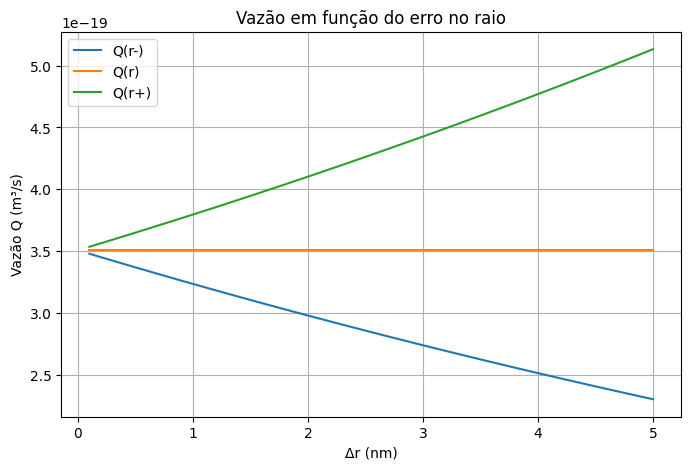

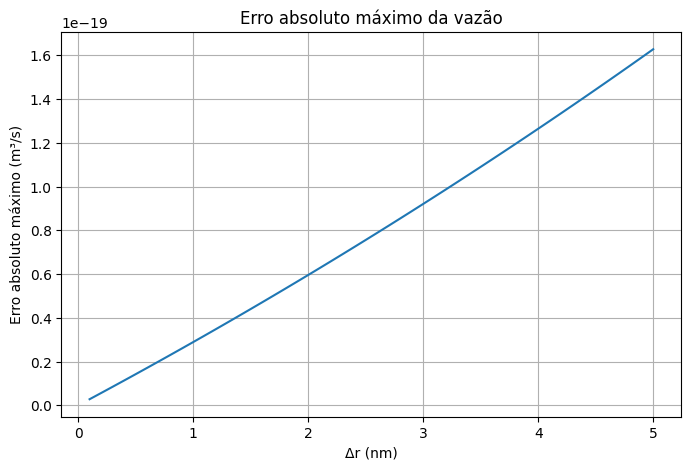

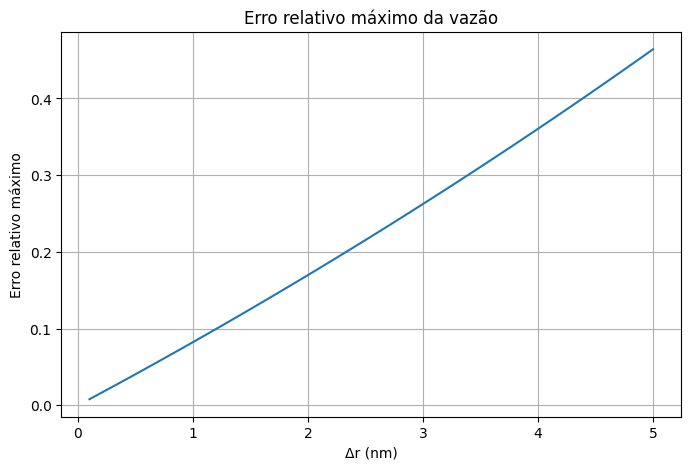

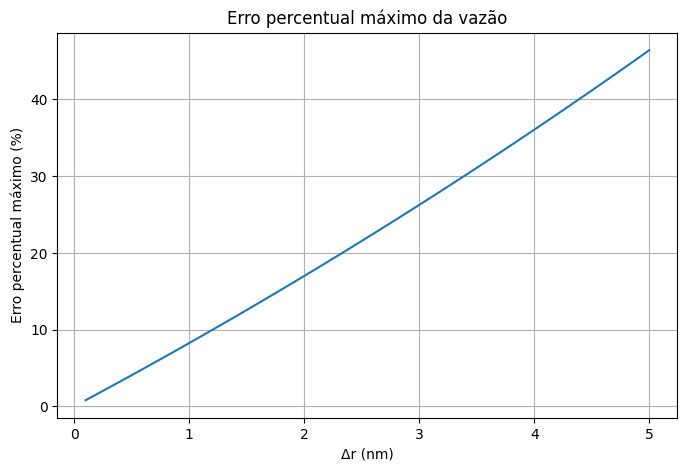

========== FLOAT32 ==========
r^4 = 6.2500004e-30
Q = 3.5062423e-19
eps = 1.1920929e-07

========== FLOAT64 ==========
r^4 = 6.249999999999999e-30
Q = 3.506241800881465e-19
eps = 2.220446049250313e-16

========== DIFERENÇAS ==========
Diferença absoluta = 5.228627689184328e-26
Diferença relativa = 1.4912342006389455e-07
            Δr/r            δ1            δ2     Diferença
0   1.000000e-01  4.641000e-01  4.641000e-01  2.220446e-16
1   1.000000e-02  4.060401e-02  4.060401e-02  1.040834e-16
2   1.000000e-03  4.006004e-03  4.006004e-03  2.211772e-16
3   1.000000e-04  4.000600e-04  4.000600e-04  1.241411e-16
4   1.000000e-05  4.000060e-05  4.000060e-05  2.265440e-16
5   1.000000e-06  4.000006e-06  4.000006e-06  5.357585e-16
6   1.000000e-07  4.000001e-07  4.000001e-07  1.866356e-16
7   1.000000e-08  4.000000e-08  4.000000e-08  3.174459e-16
8   1.000000e-09  4.000000e-09  4.000000e-09  3.667706e-16
9   1.000000e-10  4.000003e-10  4.000000e-10  2.791625e-16
10  1.000000e-12  4.000176e-1

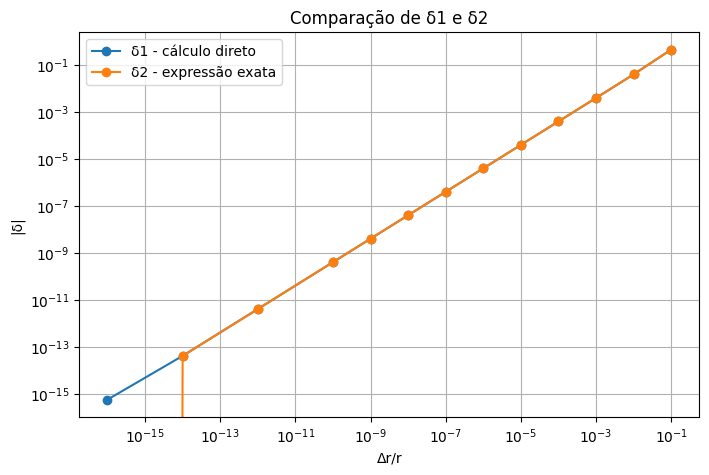

In [ ]:
#Parte D escoamento num nanocateter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dados
r_nm = 50
L_um = 10
mu = 3.5e-3
delta_p = 5000

# Conversão para metros
r = r_nm * 1e-9
L = L_um * 1e-6

# FUNÇÃO DE HAGEN-POISEUILLE
def vazao(r, delta_p, mu, L):
    return (np.pi * r**4 * delta_p) / (8 * mu * L)

# VAZÃO DE REFERÊNCIA
Q_ref = vazao(r, delta_p, mu, L)

print("Raio =", r, "m")
print("Comprimento =", L, "m")
print("Vazão de referência =", Q_ref, "m³/s")

#ERRO GEOMÉTRICO
delta_r_nm = np.arange(0.1, 5.1, 0.1)

resultados = []

for dr_nm in delta_r_nm:

    # Converter Δr para metros
    dr = dr_nm * 1e-9

    # Raios menor e maior
    r_menor = r - dr
    r_maior = r + dr

    # Vazões
    Q_menor = vazao(r_menor, delta_p, mu, L)
    Q_maior = vazao(r_maior, delta_p, mu, L)

    # Erros absolutos
    erro_menor = abs(Q_menor - Q_ref)
    erro_maior = abs(Q_maior - Q_ref)

    # Maior erro absoluto
    erro_abs_max = max(erro_menor, erro_maior)

    # Erro relativo máximo
    erro_rel_max = erro_abs_max / abs(Q_ref)

    # Erro percentual máximo
    erro_perc_max = erro_rel_max * 100

    resultados.append([
        dr_nm,
        r_menor * 1e9,
        r_maior * 1e9,
        Q_menor,
        Q_maior,
        erro_abs_max,
        erro_rel_max,
        erro_perc_max
    ])

#tabela
df_D1 = pd.DataFrame(
    resultados,
    columns=[
        "Δr (nm)",
        "r- (nm)",
        "r+ (nm)",
        "Q(r-) (m³/s)",
        "Q(r+) (m³/s)",
        "Erro absoluto máximo",
        "Erro relativo máximo",
        "Erro percentual máximo (%)"
    ]
)

print(df_D1)

#gráficos
plt.figure(figsize=(8, 5))

plt.plot(
    df_D1["Δr (nm)"],
    df_D1["Q(r-) (m³/s)"],
    label="Q(r-)"
)

plt.plot(
    df_D1["Δr (nm)"],
    [Q_ref] * len(df_D1),
    label="Q(r)"
)

plt.plot(
    df_D1["Δr (nm)"],
    df_D1["Q(r+) (m³/s)"],
    label="Q(r+)"
)

plt.xlabel("Δr (nm)")
plt.ylabel("Vazão Q (m³/s)")
plt.title("Vazão em função do erro no raio")

plt.grid()
plt.legend()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    df_D1["Δr (nm)"],
    df_D1["Erro absoluto máximo"]
)

plt.xlabel("Δr (nm)")
plt.ylabel("Erro absoluto máximo (m³/s)")
plt.title("Erro absoluto máximo da vazão")

plt.grid()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    df_D1["Δr (nm)"],
    df_D1["Erro relativo máximo"]
)

plt.xlabel("Δr (nm)")
plt.ylabel("Erro relativo máximo")
plt.title("Erro relativo máximo da vazão")

plt.grid()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    df_D1["Δr (nm)"],
    df_D1["Erro percentual máximo (%)"]
)

plt.xlabel("Δr (nm)")
plt.ylabel("Erro percentual máximo (%)")
plt.title("Erro percentual máximo da vazão")

plt.grid()

plt.show()

#FLOAT32 E FLOAT64

# Float32
r32 = np.float32(50e-9)
L32 = np.float32(10e-6)
mu32 = np.float32(3.5e-3)
dp32 = np.float32(5000)

r4_32 = r32**4

Q32 = (
    np.float32(np.pi) *
    r4_32 *
    dp32
) / (
    np.float32(8) *
    mu32 *
    L32
)


# Float64
r64 = np.float64(50e-9)
L64 = np.float64(10e-6)
mu64 = np.float64(3.5e-3)
dp64 = np.float64(5000)

r4_64 = r64**4

Q64 = (
    np.pi *
    r4_64 *
    dp64
) / (
    8 *
    mu64 *
    L64
)

# DIFERENÇAS
diferenca_absoluta = abs(Q64 - Q32)

diferenca_relativa = (
    diferenca_absoluta / abs(Q64)
)

# EPS
eps32 = np.finfo(np.float32).eps
eps64 = np.finfo(np.float64).eps


print("========== FLOAT32 ==========")
print("r^4 =", r4_32)
print("Q =", Q32)
print("eps =", eps32)

print("\n========== FLOAT64 ==========")
print("r^4 =", r4_64)
print("Q =", Q64)
print("eps =", eps64)

print("\n========== DIFERENÇAS ==========")
print("Diferença absoluta =", diferenca_absoluta)
print("Diferença relativa =", diferenca_relativa)

# CANCELAMENTO NUMÉRICO
variacoes = [
    1e-1,
    1e-2,
    1e-3,
    1e-4,
    1e-5,
    1e-6,
    1e-7,
    1e-8,
    1e-9,
    1e-10,
    1e-12,
    1e-14,
    1e-16
]

resultados_cancelamento = []

for variacao in variacoes:

    dr = r * variacao

    # Forma 1 - cálculo direto
    Q_novo = vazao(
        r + dr,
        delta_p,
        mu,
        L
    )

    delta1 = (Q_novo - Q_ref) / Q_ref

    # Forma 2 - expressão matemática
    delta2 = (1 + variacao)**4 - 1

    resultados_cancelamento.append([
        variacao,
        delta1,
        delta2,
        abs(delta1 - delta2)
    ])


df_cancelamento = pd.DataFrame(
    resultados_cancelamento,
    columns=[
        "Δr/r",
        "δ1",
        "δ2",
        "Diferença"
    ]
)

print(df_cancelamento)
plt.figure(figsize=(8, 5))

plt.loglog(
    df_cancelamento["Δr/r"],
    abs(df_cancelamento["δ1"]),
    marker="o",
    label="δ1 - cálculo direto"
)

plt.loglog(
    df_cancelamento["Δr/r"],
    abs(df_cancelamento["δ2"]),
    marker="o",
    label="δ2 - expressão exata"
)

plt.xlabel("Δr/r")
plt.ylabel("|δ|")
plt.title("Comparação de δ1 e δ2")

plt.grid()
plt.legend()

plt.show()


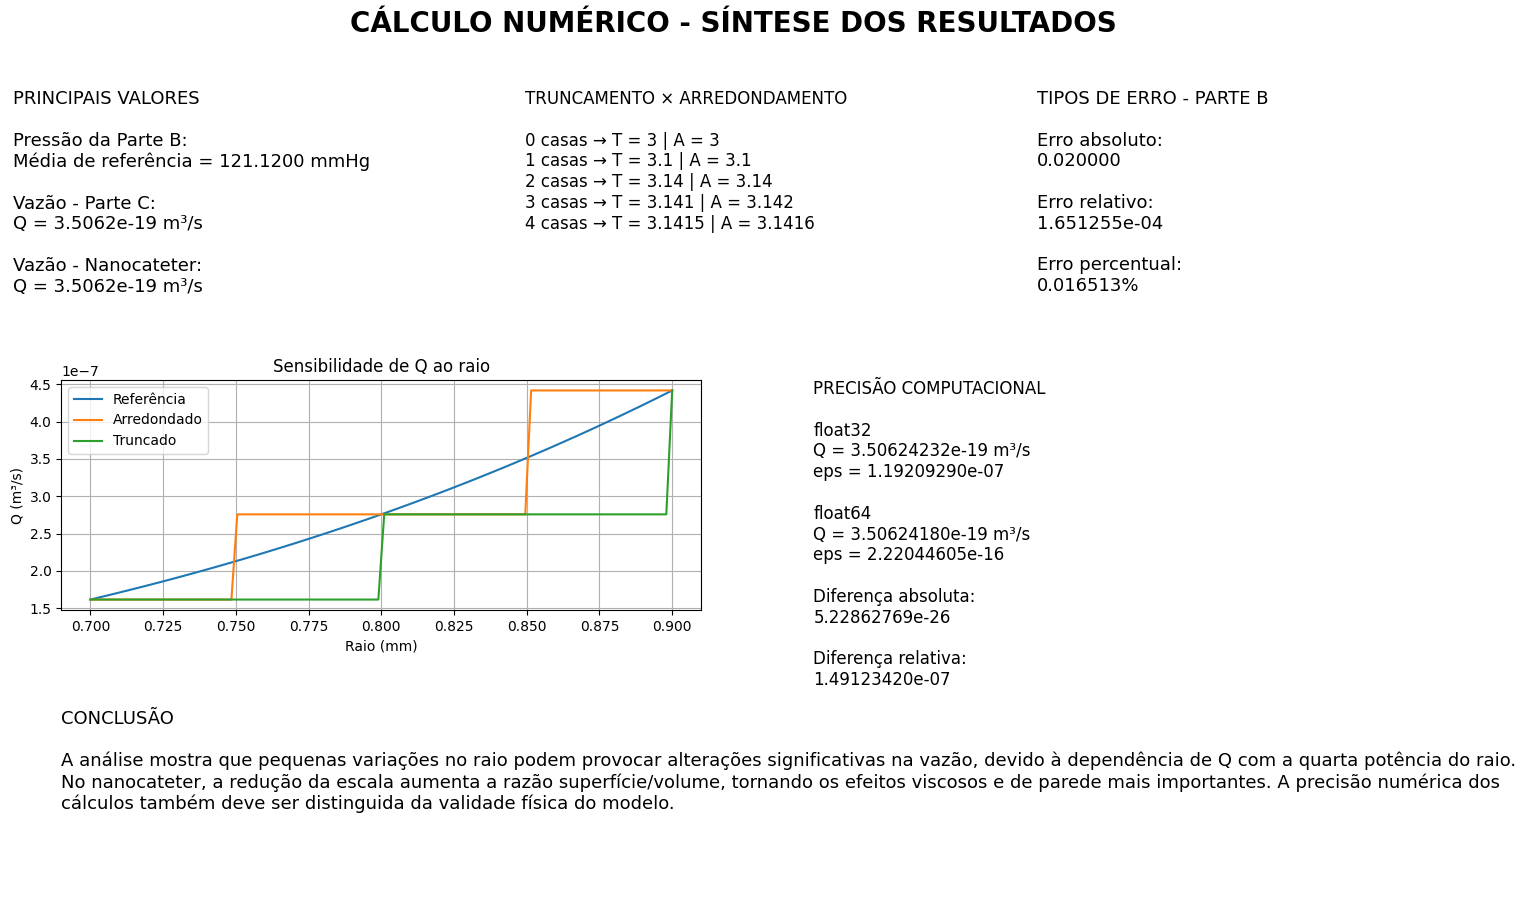

Imagem salva como: parte_E_sintese_visual.png


In [ ]:
#parte E síntese visual
import numpy as np
import matplotlib.pyplot as plt

# Criar figura com 1600 x 1000 pixels
# DPI = 100 -> 16 x 10 polegadas = 1600 x 1000 pixels
fig = plt.figure(figsize=(16, 10), dpi=100)

# Título principal
fig.suptitle(
    "CÁLCULO NUMÉRICO - SÍNTESE DOS RESULTADOS",
    fontsize=20,
    fontweight="bold"
)
#PRINCIPAIS VALORES
ax1 = fig.add_axes([0.05, 0.70, 0.27, 0.20])

ax1.axis("off")

texto_principais = (
    "PRINCIPAIS VALORES\n\n"
    f"Pressão da Parte B:\n"
    f"Média de referência = {media_referencia:.4f} mmHg\n\n"
    f"Vazão - Parte C:\n"
    f"Q = {Q_ref:.4e} m³/s\n\n"
    f"Vazão - Nanocateter:\n"
    f"Q = {Q_ref:.4e} m³/s"
)

ax1.text(
    0,
    1,
    texto_principais,
    fontsize=13,
    verticalalignment="top"
)

#TRUNCAMENTO X ARREDONDAMENTO

ax2 = fig.add_axes([0.37, 0.70, 0.27, 0.20])

ax2.axis("off")

# Escolher x1 para mostrar a comparação
dados_x1 = tabela_A[tabela_A["Valor"] == "x1"]

texto_trunc_arred = "TRUNCAMENTO × ARREDONDAMENTO\n\n"

for n in range(5):

    trunc = dados_x1[
        (dados_x1["n"] == n) &
        (dados_x1["Método"] == "Truncamento")
    ]["Aproximação"].iloc[0]

    arred = dados_x1[
        (dados_x1["n"] == n) &
        (dados_x1["Método"] == "Arredondamento")
    ]["Aproximação"].iloc[0]

    texto_trunc_arred += (
        f"{n} casas → "
        f"T = {trunc:.{n}f} | "
        f"A = {arred:.{n}f}\n"
    )

ax2.text(
    0,
    1,
    texto_trunc_arred,
    fontsize=12,
    verticalalignment="top"
)

#TRÊS TIPOS DE ERRO
ax3 = fig.add_axes([0.69, 0.70, 0.27, 0.20])

ax3.axis("off")

# Pegar o cenário truncado da Parte B
erro_b = tabela_erros[
    tabela_erros["Série"] == "Arredondados" # Changed from Truncados to Arredondados as Truncados is not in the dataframe
].iloc[0]

texto_erros = (
    "TIPOS DE ERRO - PARTE B\n\n"
    f"Erro absoluto:\n"
    f"{erro_b['Erro absoluto']:.6f}\n\n"
    f"Erro relativo:\n"
    f"{erro_b['Erro relativo']:.6e}\n\n"
    f"Erro percentual:\n"
    f"{erro_b['Erro percentual (%)']:.6f}%"
)

ax3.text(
    0,
    1,
    texto_erros,
    fontsize=13,
    verticalalignment="top"
)

#SENSIBILIDADE DA VAZÃO AO RAIO
ax4 = fig.add_axes([0.08, 0.38, 0.40, 0.23])

ax4.plot(
    raios_mm,
    Q_ref_lista,
    label="Referência"
)

ax4.plot(
    raios_mm,
    Q_arred_lista,
    label="Arredondado"
)

ax4.plot(
    raios_mm,
    Q_trunc_lista,
    label="Truncado"
)

ax4.set_xlabel("Raio (mm)")
ax4.set_ylabel("Q (m³/s)")
ax4.set_title("Sensibilidade de Q ao raio")

ax4.grid()
ax4.legend()

#COMPARAÇÃO FLOAT32 X FLOAT64
ax5 = fig.add_axes([0.55, 0.38, 0.35, 0.23])

ax5.axis("off")

texto_float = (
    "PRECISÃO COMPUTACIONAL\n\n"
    f"float32\n"
    f"Q = {Q32:.8e} m³/s\n"
    f"eps = {eps32:.8e}\n\n"
    f"float64\n"
    f"Q = {Q64:.8e} m³/s\n"
    f"eps = {eps64:.8e}\n\n"
    f"Diferença absoluta:\n"
    f"{diferenca_absoluta:.8e}\n\n"
    f"Diferença relativa:\n"
    f"{diferenca_relativa:.8e}"
)

ax5.text(
    0,
    1,
    texto_float,
    fontsize=12,
    verticalalignment="top"
)

#CONCLUSÃO SOBRE O NANOCATETER
ax6 = fig.add_axes([0.08, 0.08, 0.84, 0.20])

ax6.axis("off")

conclusao = (
    "CONCLUSÃO\n\n"
    "A análise mostra que pequenas variações no raio podem provocar "
    "alterações significativas na vazão, devido à dependência de Q com "
    "a quarta potência do raio. No nanocateter, a redução da escala "
    "aumenta a razão superfície/volume, tornando os efeitos viscosos "
    "e de parede mais importantes. A precisão numérica dos cálculos "
    "também deve ser distinguida da validade física do modelo."
)

ax6.text(
    0,
    1,
    conclusao,
    fontsize=13,
    verticalalignment="top",
    wrap=True
)

plt.savefig(
    "parte_E_sintese_visual.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

print("Imagem salva como: parte_E_sintese_visual.png")

In [ ]:
# ==========================================
# PARTE F - GIF DEMONSTRATIVO DO NANOCATETER
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. DADOS DO NANOCATETER
# ==========================================

# Raio de referência
r_ref_nm = 50

# Comprimento
L = 10e-6  # 10 micrometros

# Viscosidade
mu = 3.5e-3  # Pa.s

# Diferença de pressão
delta_p = 5000  # Pa


# ==========================================
# 2. FUNÇÃO DE HAGEN-POISEUILLE
# ==========================================

def vazao(r, delta_p, mu, L):
    """
    Calcula a vazão usando a equação
    de Hagen-Poiseuille.
    """

    return (np.pi * r**4 * delta_p) / (8 * mu * L)


# ==========================================
# 3. VAZÃO DE REFERÊNCIA
# ==========================================

r_ref = r_ref_nm * 1e-9

Q_ref = vazao(
    r_ref,
    delta_p,
    mu,
    L
)

print("Raio de referência:", r_ref_nm, "nm")
print("Vazão de referência:", Q_ref, "m³/s")


# ==========================================
# 4. VALORES DO RAIO
# ==========================================

# 50 valores entre 45 e 55 nm
raios_nm = np.linspace(45, 55, 50)

# Converter para metros
raios_m = raios_nm * 1e-9


# ==========================================
# 5. CALCULAR AS VAZÕES
# ==========================================

vazoes = []

for raio in raios_m:

    Q = vazao(
        raio,
        delta_p,
        mu,
        L
    )

    vazoes.append(Q)

vazoes = np.array(vazoes)


# ==========================================
# 6. CALCULAR ERRO PERCENTUAL
# ==========================================

erros_percentuais = (
    np.abs(vazoes - Q_ref)
    / abs(Q_ref)
    * 100
)


# ==========================================
# 7. CRIAR A FIGURA
# ==========================================

fig = plt.figure(figsize=(12, 6))

# Área da seção transversal
ax1 = fig.add_axes([0.05, 0.15, 0.35, 0.70])

# Área do gráfico Q x r
ax2 = fig.add_axes([0.50, 0.15, 0.45, 0.70])


# ==========================================
# 8. FUNÇÃO DE ATUALIZAÇÃO
# ==========================================

def atualizar(frame):

    # Limpar os dois gráficos
    ax1.clear()
    ax2.clear()


    # ======================================
    # RAIO ATUAL
    # ======================================

    raio_nm = raios_nm[frame]
    raio_m = raios_m[frame]

    Q_atual = vazoes[frame]
    erro_atual = erros_percentuais[frame]


    # ======================================
    # SEÇÃO TRANSVERSAL DO NANOCATETER
    # ======================================

    # Círculo representando o canal
    theta = np.linspace(0, 2 * np.pi, 300)

    x = raio_nm * np.cos(theta)
    y = raio_nm * np.sin(theta)

    ax1.fill(
        x,
        y,
        alpha=0.5
    )

    ax1.plot(
        x,
        y,
        linewidth=2
    )

    # Linha indicando o raio
    ax1.plot(
        [0, raio_nm],
        [0, 0],
        linewidth=2
    )

    # Texto do raio
    ax1.text(
        raio_nm / 2,
        2,
        f"r = {raio_nm:.2f} nm",
        ha="center",
        fontsize=12
    )

    # Ajustar limites
    ax1.set_xlim(-60, 60)
    ax1.set_ylim(-60, 60)

    ax1.set_aspect("equal")

    ax1.set_xlabel("nm")
    ax1.set_ylabel("nm")

    ax1.set_title(
        "Seção transversal do nanocateter"
    )

    ax1.grid(True)


    # ======================================
    # INFORMAÇÕES NUMÉRICAS
    # ======================================

    texto = (
        f"Raio atual: {raio_nm:.2f} nm\n\n"
        f"Vazão:\n"
        f"{Q_atual:.4e} m³/s\n\n"
        f"Erro percentual:\n"
        f"{erro_atual:.4f}%"
    )

    ax1.text(
        0.02,
        0.02,
        texto,
        transform=ax1.transAxes,
        fontsize=11,
        verticalalignment="bottom"
    )


    # ======================================
    # CURVA Q x r
    # ======================================

    # Mostrar somente os valores calculados
    # até o quadro atual
    ax2.plot(
        raios_nm[:frame + 1],
        vazoes[:frame + 1],
        linewidth=2
    )

    # Ponto atual
    ax2.plot(
        raio_nm,
        Q_atual,
        marker="o",
        markersize=7
    )

    # Linha da vazão de referência
    ax2.axhline(
        Q_ref,
        linestyle="--",
        label="Q em r = 50 nm"
    )

    ax2.set_xlim(45, 55)

    # Limites verticais
    margem = (max(vazoes) - min(vazoes)) * 0.1

    ax2.set_ylim(
        min(vazoes) - margem,
        max(vazoes) + margem
    )

    ax2.set_xlabel("Raio (nm)")
    ax2.set_ylabel("Vazão Q (m³/s)")

    ax2.set_title(
        "Construção progressiva da curva Q × r"
    )

    ax2.grid(True)

    ax2.legend()

    fig.suptitle(
        f"Nanocateter — Quadro {frame + 1}/50",
        fontsize=16,
        fontweight="bold"
    )

animacao = FuncAnimation(
    fig,
    atualizar,
    frames=len(raios_nm),
    interval=100,
    repeat=True
)
# 10. SALVAR GIF
animacao.save(
    "nanocateter.gif",
    writer=PillowWriter(fps=10)
)

plt.close(fig)

print("\n======================================")
print("GIF GERADO COM SUCESSO!")
print("======================================")
print("Arquivo: nanocateter.gif")
print("Número de quadros:", len(raios_nm))
print("Raio inicial:", raios_nm[0], "nm")
print("Raio final:", raios_nm[-1], "nm")

Raio de referência: 50 nm
Vazão de referência: 3.5062418008814665e-19 m³/s

GIF GERADO COM SUCESSO!
Arquivo: nanocateter.gif
Número de quadros: 50
Raio inicial: 45.0 nm
Raio final: 55.0 nm
